In [2]:
import numpy as np
import matplotlib as mt
import pandas as pd

Валидация данных

In [3]:
df_train = pd.read_json('train.jsonl', lines=True)
df_val   = pd.read_json('validation.jsonl', lines=True)
df_test  = pd.read_json('test.jsonl', lines=True)

df_train.head()

,id,text,label,label_text
0,0,"Если честно, меня не очень впечатлила новость,...",2,Good
1,1,"Сразу скажу — книгу я не читала, поэтому о том...",0,Bad
2,2,Общее впечатление таково: фильм не назовешь пл...,1,Neutral
3,3,Только что посмотрела этот «фильм». Рецензии п...,0,Bad
4,4,"Скажу сразу же, фильм — гениален! Если есть те...",2,Good


# Разведка
Воспользуемся моделью от вк, это по-русски, православно, самодержавно, народно. Будем fine-tunить их RuModernBert. Результаты на бенчмарках Russian SuperGLUE и Encodechka:

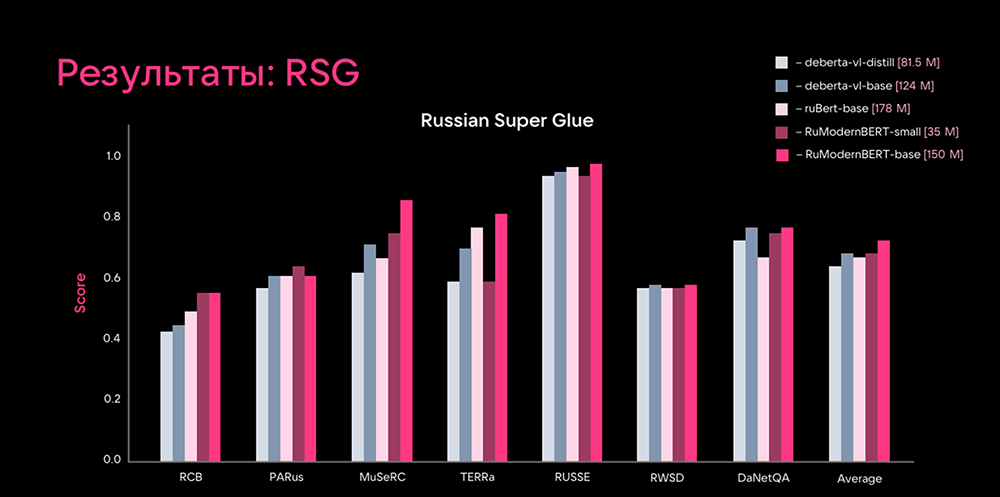
#
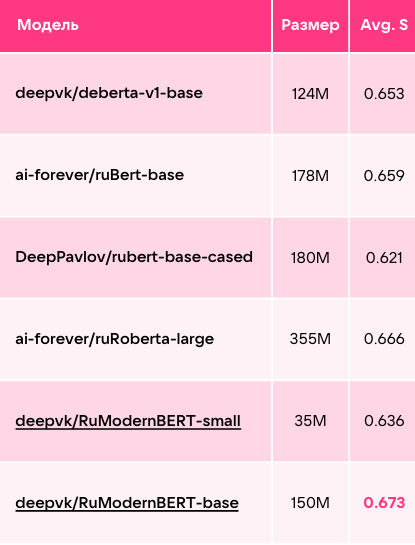

Архитектура новее: RoPE, GeGLU, чередующееся внимание. При том же размере качество обычно немного выше.
Скорость: unpadding и FlashAttention ускоряют обучение и инференс, особенно на текстах разной длины.
Контекст: до 8k токенов против 512 у ruBERT. Для длинных отзывов не придётся обрезать текст.
Данные свежее: современный сленг, интернет-лексика и код, а тональность живёт как раз в такой лексике.

Коннект с HF

In [4]:
import os
from dotenv import load_dotenv

load_dotenv()
hf_token = os.getenv("HF_TOKEN")

from transformers import AutoTokenizer, AutoModelForSequenceClassification
model_id = "deepvk/RuModernBERT-base"
model = AutoModelForSequenceClassification.from_pretrained(model_id, num_labels=3)
tokenizer = AutoTokenizer.from_pretrained(model_id)

/home/kagor/work_model/trainings/task5/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 136/136 [00:00<00:00, 2854.10it/s]
[transformers] ModernBertForSequenceClassification LOAD REPORT from: deepvk/RuModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# Понимаем как в среднем разбить отзыв

In [5]:
texts = df_train["text"].tolist()
av_len = sum(len(t) for t in texts)/len(texts) #1907.9404761904761
max_len = max(len(t) for t in texts)
token_lenghts = [len(tokenizer.encode(t, truncation=False)) for t in texts]
av_token_lenght = sum(token_lenghts)/len(token_lenghts) # 504.0630476190476
max_token_lenght = max(token_lenghts) # 5455
import numpy as np
median = np.median(token_lenghts) # 416

In [ ]:
av_len, av_token_lenght, median

(1907.9404761904761, 504.0630476190476, np.float64(416.0))

In [ ]:
from datasets import Dataset # Переводим всё в датасеты и обрезаем для обработки тренером

ds_train = Dataset.from_pandas(df_train)
ds_val   = Dataset.from_pandas(df_val)
ds_test  = Dataset.from_pandas(df_test)

ds_train = ds_train.map(lambda b: tokenizer(b["text"], truncation=True, max_length=1024), batched=True)
ds_val = ds_val.map(lambda b: tokenizer(b["text"], truncation=True, max_length=1024), batched=True)
ds_test = ds_test.map(lambda b: tokenizer(b["text"], truncation=True, max_length=1024), batched=True)

Map: 100%|██████████| 1500/1500 [00:00<00:00, 3929.76 examples/s]


In [ ]:
ds_train = ds_train.rename_column("label", "labels") # Стандарт labels в HF
ds_val   = ds_val.rename_column("label", "labels")
ds_test  = ds_test.rename_column("label", "labels")

# compute_metrics для метрик нужных

In [ ]:
from transformers import DataCollatorWithPadding
from sklearn.metrics import accuracy_score, f1_score

collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="macro"),
    }

# Подбор гиперпараметров за скобками, сейчас тренировка

In [ ]:
from transformers import Trainer, TrainingArguments

args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit=2,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=ds_train,
    eval_dataset=ds_val,
    processing_class=tokenizer,
    data_collator=collator,
    compute_metrics=compute_metrics,
)
trainer.train()
trainer.predict(ds_test)

ImportError: Using the `Trainer` with `PyTorch` requires `accelerate>=1.1.0`: Please run `pip install transformers[torch]` or `pip install 'accelerate>=1.1.0'`

              precision    recall  f1-score   support

         Bad      0.822     0.796     0.809       500
     Neutral      0.594     0.588     0.591       500
        Good      0.758     0.790     0.774       500

    accuracy                          0.725      1500
   macro avg      0.725     0.725     0.725      1500
weighted avg      0.725     0.725     0.725      1500